In [1]:
import sys
from pathlib import Path
ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# -- Define the move to inspect ---------------------------------------------
# Set the start and end date of the move you want to analyze.
# Format: "YYYY-MM-DD HH:MM" in UTC. Use "00:00" for start of day.
MOVE_START = "2026-03-16 00:00"
MOVE_END   = "2026-03-29 23:00"

# Symbol to fetch from Binance
BINANCE_SYMBOL = "ETHUSDT"

# -- Filter settings -- same as notebook 08 --------------------------------
USE_PARENT_RELATIVE_FILTER = True
MIN_IMPULSE_PARENT_RATIO   = 0.15
USE_MOMENTUM_FILTER        = True
MIN_MOMENTUM_RATIO         = 0.5
USE_DOMINANCE_FILTER       = True
MIN_DOMINANCE_RATIO        = 1.5

FILTER_CONFIG = {
    "use_parent_relative_filter": USE_PARENT_RELATIVE_FILTER,
    "min_impulse_parent_ratio":   MIN_IMPULSE_PARENT_RATIO,
    "use_momentum_filter":        USE_MOMENTUM_FILTER,
    "min_momentum_ratio":         MIN_MOMENTUM_RATIO,
    "use_dominance_filter":       USE_DOMINANCE_FILTER,
    "min_dominance_ratio":        MIN_DOMINANCE_RATIO,
}

# -- Timeframe stepping order ------------------------------------------------
# System tries each timeframe in order and stops at the first one
# that finds 3 or more confirmed legs.
TIMEFRAME_ORDER = ["4h", "1h", "15m", "5m"]

# Minimum confirmed legs required before the system accepts a timeframe
MIN_LEGS = 3

In [2]:
from datetime import datetime, timezone

from src.adapters.binance_data import fetch_binance_ohlc_sync

from src.core.trend_id import identify_trend, compute_internal_structure



move_start_dt = datetime.strptime(MOVE_START, "%Y-%m-%d %H:%M").replace(tzinfo=timezone.utc)

move_end_dt   = datetime.strptime(MOVE_END,   "%Y-%m-%d %H:%M").replace(tzinfo=timezone.utc)



selected_tf = None

selected_candles = None

selected_result = None



for tf in TIMEFRAME_ORDER:

    try:

        tf_candles = fetch_binance_ohlc_sync(

            BINANCE_SYMBOL,

            tf,

            start_time=move_start_dt,

        )

    except Exception as exc:

        print(f"[SKIP] {tf}: fetch failed - {exc}")

        continue



    tf_slice = [

        candle for candle in tf_candles

        if move_start_dt <= candle.timestamp <= move_end_dt

    ]



    if len(tf_slice) < 10:

        print(f"[SKIP] {tf}: only {len(tf_slice)} candles in range - too few")

        continue



    result = identify_trend(tf_slice, **FILTER_CONFIG)

    compute_internal_structure(

        tf_slice,

        result["legs"],

        **FILTER_CONFIG,

    )



    confirmed_outer_legs = [leg for leg in result["legs"] if leg.get("confirmed")]

    confirmed_internal_legs = [

        internal_leg

        for leg in result["legs"]

        for internal_leg in (leg.get("internal_structure") or {}).get("legs", [])

        if internal_leg.get("confirmed")

    ]

    total_confirmed_legs = len(confirmed_outer_legs) + len(confirmed_internal_legs)



    print(

        f"[TRY]  {tf}: {len(tf_slice)} candles - outer={len(confirmed_outer_legs)} - internal={len(confirmed_internal_legs)} - total={total_confirmed_legs} - trend: {result['trend']}"

    )



    if len(tf_slice) < 100:

        print(f"[SKIP] {tf}: only {len(tf_slice)} candles in range - too coarse for move inspection")

        continue



    if total_confirmed_legs >= MIN_LEGS:

        selected_tf = tf

        selected_candles = tf_slice

        selected_result = result

        print(f"[USE]  {tf}: found {total_confirmed_legs} confirmed structural legs - using this timeframe")

        break



if selected_tf is None:

    print("No timeframe found with enough structure. Try widening the date range or lowering MIN_LEGS.")

else:

    print()

    print(f"Selected timeframe: {selected_tf}")

    print(f"Candles in range:   {len(selected_candles)}")

    print(f"Trend direction:    {selected_result['trend']}")

    print(f"Confirmed outer legs: {len([leg for leg in selected_result['legs'] if leg.get('confirmed')])}")

    print(f"Confirmed internal legs: {sum(1 for leg in selected_result['legs'] for internal_leg in (leg.get('internal_structure') or {}).get('legs', []) if internal_leg.get('confirmed'))}")

    print(f"Current phase:      {selected_result['current_phase']}")


[TRY]  4h: 82 candles - outer=2 - internal=2 - total=4 - trend: down
[SKIP] 4h: only 82 candles in range - too coarse for move inspection
[TRY]  1h: 325 candles - outer=2 - internal=6 - total=8 - trend: down
[USE]  1h: found 8 confirmed structural legs - using this timeframe

Selected timeframe: 1h
Candles in range:   325
Trend direction:    down
Confirmed outer legs: 2
Confirmed internal legs: 6
Current phase:      retracement


BOS | price=2023.04 | start=175 (2026-03-23 07:00:00+00:00) | end=324 (2026-03-29 12:00:00+00:00) | broken=True


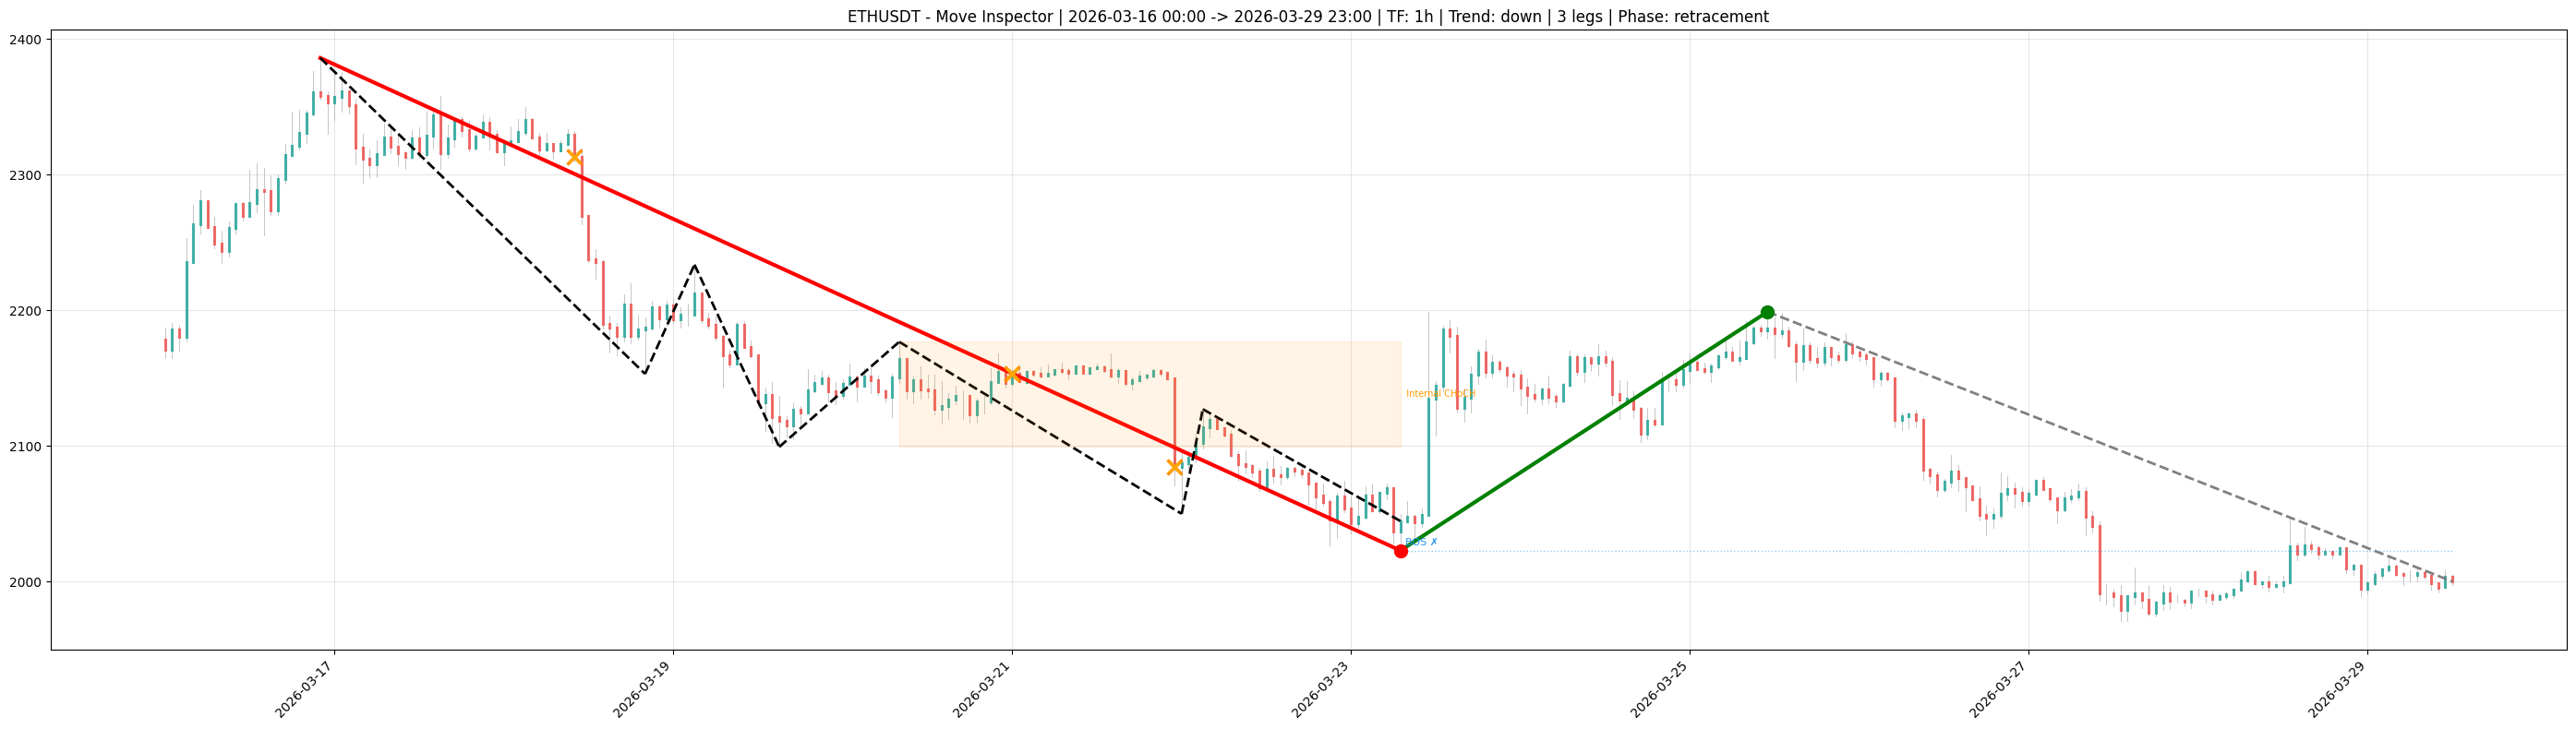


=== What you are looking at ===
- Timeframe used: 1h (first timeframe with 3+ confirmed legs)
- Date range: 2026-03-16 00:00 -> 2026-03-29 23:00
- Colored lines: impulse and retracement legs
- Black dotted lines: internal structure within each confirmed impulse
- Horizontal lines: BOS and CHoCH levels
- Shaded bands: CHoCH zones


In [3]:
if selected_tf is None:

    print("Nothing to draw - no timeframe found with enough structure.")

else:

    import matplotlib.pyplot as plt

    import matplotlib.dates as mdates

    from src.core.choch_zone import get_active_choch_zone

    from src.visualization.trend_chart import draw_trend_chart



    fig, ax = plt.subplots(figsize=(28, 8))

    ax = draw_trend_chart(

        selected_candles,

        selected_result,

        f"{BINANCE_SYMBOL} - Move Inspector | {MOVE_START} -> {MOVE_END} | TF: {selected_tf}",

        use_datetime_axis=True,

        ax=ax,

    )



    global_choch_result = get_active_choch_zone(

        selected_result["legs"],

        selected_result["trend"],

        selected_candles,

    )

    if global_choch_result and global_choch_result.get("choch_zone"):

        zone = global_choch_result["choch_zone"]

        lower = float(zone["lower_boundary"])

        upper = float(zone["upper_boundary"])

        source_idx = zone.get("source_impulse_start_index", 0)

        ts_start = selected_candles[int(source_idx)].timestamp

        ts_end = selected_candles[-1].timestamp

        ax.fill_between(

            [ts_start, ts_end],

            lower,

            upper,

            alpha=0.12,

            color="#E91E63",

            zorder=2,

        )

        mid = (lower + upper) / 2

        ax.text(

            ts_end,

            mid,

            "  Global CHoCH",

            color="#E91E63",

            fontsize=8,

            ha="left",

            va="center",

        )



    INTERNAL_CHOCH_COLOR = "#FF9800"



    for leg in selected_result["legs"]:

        if not leg.get("confirmed"):

            continue

        if leg.get("type") != "impulse":

            continue

        if leg.get("end_index") is None:

            continue

        internal = leg.get("internal_structure")

        if internal is None:

            continue



        parent_start = int(leg["start_index"])

        parent_end = int(leg["end_index"])

        internal_candles = selected_candles[parent_start : parent_end + 1]



        internal_choch_result = get_active_choch_zone(

            internal["legs"],

            internal["trend"],

            internal_candles,

        )

        if not internal_choch_result or not internal_choch_result.get("choch_zone"):

            confirmed_retracements = [

                l for l in internal["legs"]

                if l.get("type") == "retracement"

                and l.get("confirmed")

                and l.get("start_price") is not None

                and l.get("end_price") is not None

            ]

            if not confirmed_retracements:

                continue

            last_ret = confirmed_retracements[-1]

            lower = min(float(last_ret["start_price"]), float(last_ret["end_price"]))

            upper = max(float(last_ret["start_price"]), float(last_ret["end_price"]))

            zone = {

                "lower_boundary": lower,

                "upper_boundary": upper,

                "source_impulse_start_index": last_ret.get("start_index", 0),

            }

        else:

            zone = internal_choch_result["choch_zone"]



        lower = float(zone["lower_boundary"])

        upper = float(zone["upper_boundary"])

        source_idx = zone.get("source_impulse_start_index", 0)

        global_source_idx = parent_start + int(source_idx)

        global_source_idx = max(0, min(global_source_idx, len(selected_candles) - 1))



        ts_start = selected_candles[global_source_idx].timestamp

        ts_end = selected_candles[parent_end].timestamp



        ax.fill_between(

            [ts_start, ts_end],

            lower,

            upper,

            alpha=0.10,

            color=INTERNAL_CHOCH_COLOR,

            zorder=2,

        )

        mid = (lower + upper) / 2

        ax.text(

            ts_end,

            mid,

            "  Internal CHoCH",

            color=INTERNAL_CHOCH_COLOR,

            fontsize=7,

            ha="left",

            va="center",

        )



    plt.tight_layout()

    plt.show()



    print()

    print("=== What you are looking at ===")

    print(f"- Timeframe used: {selected_tf} (first timeframe with {MIN_LEGS}+ confirmed legs)")

    print(f"- Date range: {MOVE_START} -> {MOVE_END}")

    print("- Colored lines: impulse and retracement legs")

    print("- Black dotted lines: internal structure within each confirmed impulse")

    print("- Horizontal lines: BOS and CHoCH levels")

    print("- Shaded bands: CHoCH zones")
